# Introduction

<center><img src="data/img.png" height=400></center>

This dataset was scraped from nextspaceflight and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [4]:
df_data = pd.read_csv('data/mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
print(f"What is the shape of df_data? A: {df_data.shape}\n")
print(f"How many rows and columns does it have? A: rows {df_data.shape[0]}, columns {df_data.shape[1]}\n")
print(f"What are the column names? A: {df_data.columns}\n")
print(f"Are there any NaN values or duplicates? A: {df_data.isnull().values.any()}")

What is the shape of df_data? A: (4324, 9)

How many rows and columns does it have? A: rows 4324, columns 9

What are the column names? A: Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='str')

Are there any NaN values or duplicates? A: True


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [6]:
protected_cols = ["Price"]

df_clean = df_data.drop_duplicates() # remove duplicates

# Remove columns with too many NaN (>70%)
nan_ratio = df_clean.isna().mean()
high_nan_cols = nan_ratio[nan_ratio > 0.7].index.tolist()

constant_cols = [col for col in df_clean.columns if df_clean[col].nunique() == 1] # remove columns ID-like (all unique rows)

id_like_cols = [col for col in df_clean.columns if df_clean[col].is_unique]

numeric_df = df_clean.select_dtypes(include='number')
low_variance_cols = numeric_df.columns[numeric_df.std() < 0.01].tolist()

junk_cols = list(set(high_nan_cols + constant_cols + id_like_cols + low_variance_cols))
junk_cols = [col for col in junk_cols if col not in protected_cols]

df_clean = df_clean.drop(columns=junk_cols)

## Descriptive Statistics

In [7]:
df_clean.describe()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4324,4324,4324,4324,4324,964,4324
unique,56,137,4319,4278,2,56,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Wed Nov 05, 2008 00:15 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,450.0,Success
freq,1777,235,2,6,3534,136,3879


- **Organisation** is dominated by RVSN USSR.
- **Location** is diverse, but Baikonur is the most common site.
- **Date** and **Detail** are almost entirely unique → they behave like identifiers.
- **Rocket Status** is mostly “Retired”.
- **Price** has many missing values and varies widely; 450M appears most often.
- **Mission Status** is overwhelmingly “Success”.

👉 **In short:** the dataset is large, mostly successful missions, dominated by USSR launches, with unique identifiers and incomplete price data.

# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

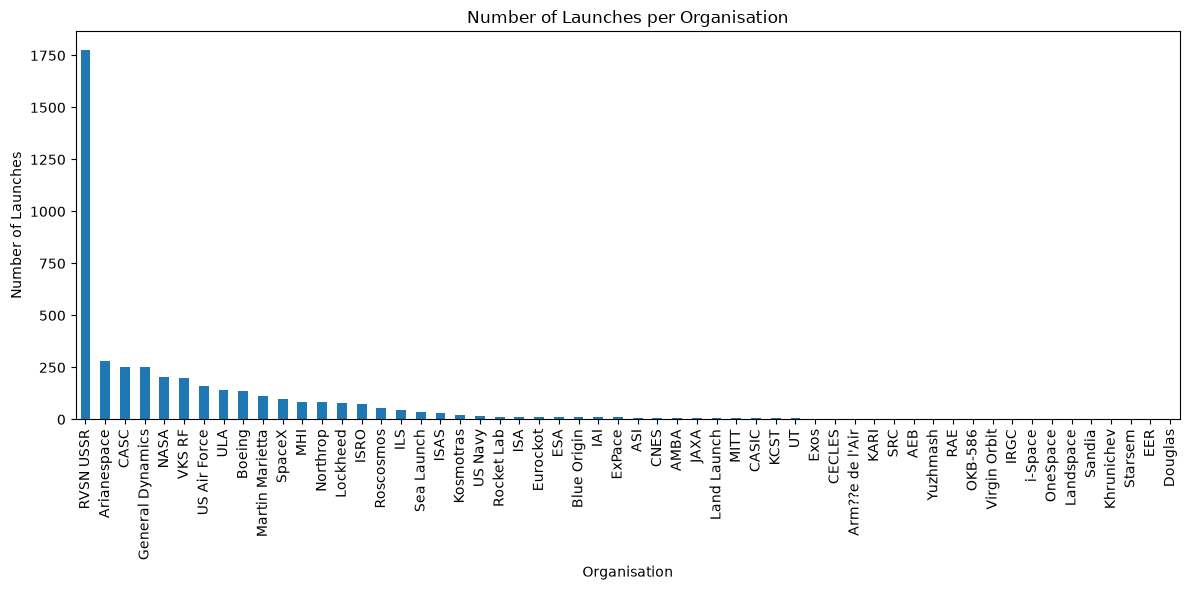

In [8]:
# Count launches per organisation
launches_per_org = df_clean['Organisation'].value_counts()

# Plot
plt.figure(figsize=(12,6))
launches_per_org.plot(kind='bar')
plt.title("Number of Launches per Organisation")
plt.xlabel("Organisation")
plt.ylabel("Number of Launches")
plt.tight_layout()
plt.show()

- **RVSN USSR** dominates with far more launches than any other organisation.
- Other major players like **Arianespace**, **CASC**, and **NASA** follow but at much lower levels.
- Most organisations have relatively few launches, showing a **strong historical concentration** of space activity in the USSR.

👉 **In summary:** space launches are heavily dominated by the USSR, with a long tail of smaller contributors.

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

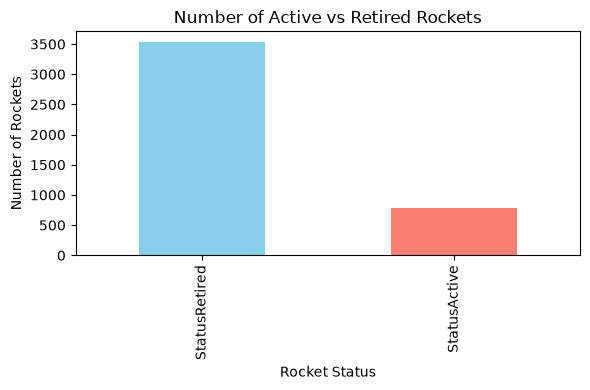

In [9]:
# Count rockets by status
rocket_status_counts = df_clean['Rocket_Status'].value_counts()

# Plot
plt.figure(figsize=(6,4))
rocket_status_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Number of Active vs Retired Rockets")
plt.xlabel("Rocket Status")
plt.ylabel("Number of Rockets")
plt.tight_layout()
plt.show()

- Most rockets are **retired**, with over 3,500 counted.
- Only a small portion — around **750** — remain **active**.

👉 **In summary:** the majority of rockets are decommissioned, showing a clear historical decline in active use.

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

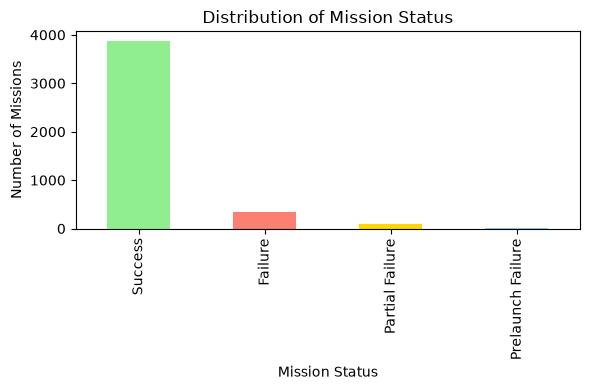

In [10]:
# Count missions by status
mission_status_counts = df_clean['Mission_Status'].value_counts()

# Plot
plt.figure(figsize=(6,4))
mission_status_counts.plot(kind='bar', color=['lightgreen', 'salmon', 'gold', 'skyblue'])
plt.title("Distribution of Mission Status")
plt.xlabel("Mission Status")
plt.ylabel("Number of Missions")
plt.tight_layout()
plt.show()

- Most missions were **successful**, nearly 4,000 in total.
- Only a small number **failed** or had **partial/prelaunch failures**.

👉 In summary: **space missions show a very high success rate with few failures overall.**

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

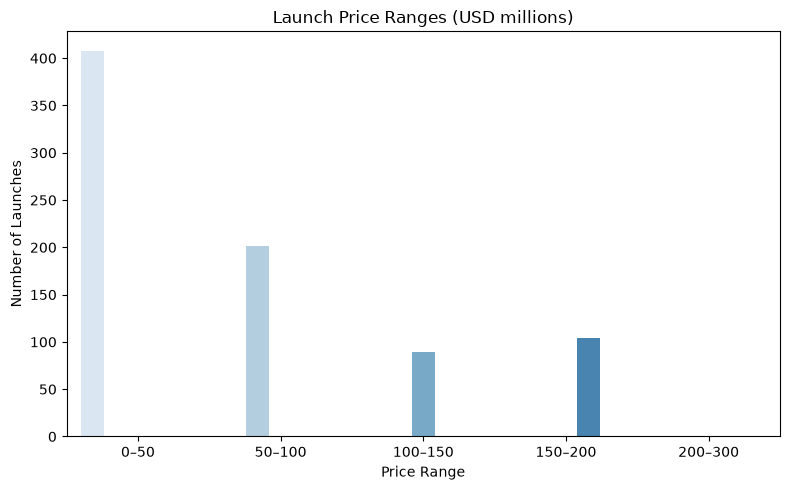

In [11]:
# Convert Price to numeric, forcing errors to NaN
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')

# Remove missing values
price_data = df_clean['Price'].dropna()

# Create price ranges
bins = [0, 50, 100, 150, 200, 300]
labels = ['0–50', '50–100', '100–150', '150–200', '200–300']
df_clean['Price_Range'] = pd.cut(price_data, bins=bins, labels=labels, include_lowest=True)

# Plot
plt.figure(figsize=(8,5))
sns.countplot(x='Price_Range', data=df_clean, palette='Blues', hue='Price_Range', legend=False)
plt.title("Launch Price Ranges (USD millions)")
plt.xlabel("Price Range")
plt.ylabel("Number of Launches")
plt.tight_layout()
plt.show()

- Most launches cost **under 50 million USD**, showing that low‑budget missions dominate.
- Launches between **50 and 200 million USD** occur less often.
- Very few exceed **200 million USD**.

👉 **In summary:** launch prices are concentrated in the lower ranges, with high‑cost missions being rare.

# Show the Number of Launches by Country

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

You can use the iso3166 package to convert the country names to Alpha3 format.

In [12]:
df_clean['Country'] = df_clean['Location'].apply(lambda x: x.split(',')[-1].strip())
df_clean['Country'] = df_clean['Country'].replace({
    'Russia': 'Russian Federation',
    'New Mexico': 'USA',
    'Yellow Sea': 'China',
    'Shahrud Missile Test Site': 'Iran',
    'Pacific Missile Range Facility': 'USA',
    'Barents Sea': 'Russian Federation',
    'Gran Canaria': 'USA'
})

def get_alpha3(name):
    try:
        return countries.get(name).alpha3
    except KeyError:
        return None

df_clean['ISO'] = df_clean['Country'].apply(get_alpha3)

launches_by_country = (
    df_clean.groupby(['Country', 'ISO'])
            .size()
            .reset_index(name='Launches')
)

fig = px.choropleth(
    launches_by_country,
    locations='ISO',                # 3‑letter country code
    color='Launches',                # number of launches
    hover_name='Country',            # show country name on hover
    color_continuous_scale='matter', # your preferred color scale
    title='Number of Launches by Country'
)

fig.show()

- The **USA**, **Russia**, and **China** dominate global launch activity.
- Other countries like **India**, **Japan**, and **Brazil** contribute far fewer launches.
- The distribution shows a **strong concentration of launches in major space powers**, with limited participation elsewhere.

👉 **In summary:** space launches are heavily concentrated in a few leading nations.

# Show the Number of Failures by Country


In [13]:
failures = df_clean[df_clean['Mission_Status'] == 'Failure']

failures_by_country = (
    failures.groupby(['Country', 'ISO'])
            .size()
            .reset_index(name='Failures')
)

fig = px.choropleth(
    failures_by_country,
    locations='ISO',
    color='Failures',
    hover_name='Country',
    color_continuous_scale='matter',
    title='Number of Launch Failures by Country'
)

fig.show()

- The **USA** and **Russia** have the **highest number of launch failures**, reflecting their long histories and high launch volumes.
- **China** and **India** show moderate failure counts.
- Other countries have **few or no failures**, indicating limited launch activity.

👉 **In summary:** launch failures are concentrated in major spacefaring nations with extensive programs.

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [14]:
fig = px.sunburst(
    df_clean,
    path=['Country', 'Organisation', 'Mission_Status'],  # hierarchical levels
    color='Mission_Status',                              # color by success/failure
    color_discrete_map={
        'Success': 'green',
        'Failure': 'red',
        'Partial Failure': 'orange',
        'Prelaunch Failure': 'gray'
    },
    title='Launches by Country, Organisation, and Mission Status'
)

fig.show()

- The **USA** and **Russia/USSR** dominate global launches, with many active organisations.
- Most missions across all countries ended in **success**, shown by the large green segments.
- **Failures** are relatively small, concentrated in a few organisations.

👉 **In summary:** major space powers lead in launch volume and maintain high success rates overall.

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [15]:
# Remove missing prices
df_price = df_clean.dropna(subset=['Price'])

# Group by organisation and sum total spending
spending_by_org = (
    df_price.groupby('Organisation')['Price']
            .sum()
            .reset_index()
            .sort_values(by='Price', ascending=False)
)

# Plot total spending
fig = px.bar(
    spending_by_org,
    x='Organisation',
    y='Price',
    color='Price',
    color_continuous_scale='matter',
    title='Total Amount Spent by Organisation on Space Missions (USD millions)'
)

fig.show()

- **NASA** spends by far the most on space missions, exceeding all other organisations.
- **Arianespace** and **ULA** follow at a distant second and third.
- Most other agencies, including **SpaceX**, **CASC**, and **ISRO**, spend significantly less.

👉 **In summary:** NASA dominates global space spending, showing its scale and investment in exploration.

# Analyse the Amount of Money Spent by Organisation per Launch

In [16]:
# Calculate total spending and number of launches per organisation
spending_stats = (
    df_price.groupby('Organisation')
            .agg(Total_Spent=('Price', 'sum'),
                 Launches=('Organisation', 'count'))
            .reset_index()
)

# Compute average cost per launch
spending_stats['Avg_Cost_Per_Launch'] = spending_stats['Total_Spent'] / spending_stats['Launches']

# Sort by average cost
spending_stats = spending_stats.sort_values(by='Avg_Cost_Per_Launch', ascending=False)

# Plot average cost per launch
fig = px.bar(
    spending_stats,
    x='Organisation',
    y='Avg_Cost_Per_Launch',
    color='Avg_Cost_Per_Launch',
    color_continuous_scale='matter',
    title='Average Cost per Launch by Organisation (USD millions)'
)

fig.show()

- **NASA** has the **highest average cost per launch**, far above all other organisations.
- **Boeing**, **ULA**, and **Arianespace** also show high spending per mission.
- **SpaceX**, **ISRO**, and **Rocket Lab** operate with **much lower costs**, reflecting efficiency and reusable technology.

👉 **In summary:** traditional agencies spend far more per launch, while newer commercial players achieve lower average costs.

# Chart the Number of Launches per Year

In [17]:
df_clean['Year'] = pd.to_datetime(df_clean['Date'], errors='coerce').dt.year

# Count launches per year
launches_per_year = (
    df_clean.groupby('Year')
            .size()
            .reset_index(name='Launches')
)

# Plot line chart
fig = px.line(
    launches_per_year,
    x='Year',
    y='Launches',
    markers=True,
    title='Number of Launches per Year'
)

fig.show()

- Launch activity **rose sharply in the 1960s and 1970s**, peaking around 1970.
- There was a **decline after 1980**, with moderate fluctuations for several decades.
- Launches **surged again after 2010**, reaching another peak around 2018–2019.

👉 **In summary:** space launches grew rapidly during the early space race, stabilized for years, and have recently increased again with modern commercial space efforts.

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

In [18]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract year‑month cleanly (no Period, no warnings)
df_clean['Month'] = df_clean['Date'].dt.to_period('M').dt.to_timestamp()

# Count launches per month
monthly_launches = (
    df_clean.groupby('Month')
            .size()
            .reset_index(name='Launches')
)

# Rolling average (6 months)
monthly_launches['Rolling_Avg'] = monthly_launches['Launches'].rolling(window=6).mean()

# Highest month
peak_month = monthly_launches.loc[monthly_launches['Launches'].idxmax(), 'Month']
peak_value = monthly_launches['Launches'].max()
print(f"Highest number of launches: {peak_value} in {peak_month.strftime('%B %Y')}")

# Plot
fig = px.line(
    monthly_launches,
    x='Month',
    y='Launches',
    title='Monthly Launches with Rolling Average'
)

fig.add_scatter(
    x=monthly_launches['Month'],
    y=monthly_launches['Rolling_Avg'],
    mode='lines',
    name='6‑Month Rolling Average',
    line=dict(color='orange', width=3)
)

fig.show()

Highest number of launches: 16 in April 1968


/var/folders/yj/kmvp6mln3p5f5324fwr_502h0000gn/T/ipykernel_3389/1302977473.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_clean['Month'] = df_clean['Date'].dt.to_period('M').dt.to_timestamp()


- Launch activity peaked in the **late 1960s and early 1970s**, reflecting the space race era.
- It then **declined steadily** through the 1980s and 1990s.
- A **new rise** began after **2010**, driven by commercial space companies.

👉 **In summary:** space launches show cyclical growth — early exploration peaks, long stagnation, and modern resurgence.

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [19]:
# Ensure Date is datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract month name
df_clean['Month'] = df_clean['Date'].dt.month_name()

# Count launches per month
launches_per_month = (
    df_clean.groupby('Month')
            .size()
            .reset_index(name='Launches')
)

# Order months correctly
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

launches_per_month['Month'] = pd.Categorical(
    launches_per_month['Month'],
    categories=month_order,
    ordered=True
)

launches_per_month = launches_per_month.sort_values('Month')

# Plot
fig = px.bar(
    launches_per_month,
    x='Month',
    y='Launches',
    title='Launches per Month'
)

fig.show()

- **December** has the **highest number of launches**, making it the most popular month.
- **January** shows the **lowest activity**, suggesting fewer missions early in the year.
- Overall, launches are **fairly consistent** across months, but **summer and winter peaks** (June and December) stand out.

👉 **In summary:** space missions tend to cluster around **mid‑year and year‑end**, likely due to favorable weather and scheduling cycles.

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

In [20]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract year
df_clean['Year'] = df_clean['Date'].dt.year

# Remove missing prices
df_price = df_clean.dropna(subset=['Price'])

# Calculate average price per year
avg_price_per_year = (
    df_price.groupby('Year')['Price']
            .mean()
            .reset_index()
)

# Plot line chart
fig = px.line(
    avg_price_per_year,
    x='Year',
    y='Price',
    markers=True,
    title='Average Launch Price Over Time (USD millions)'
)

fig.show()

- Launch prices **peaked sharply in the early 1980s**, reaching over **\$400 million** per launch.
- After that, costs **fluctuated** but showed a **steady decline** from the 1990s onward.
- By **2020**, average prices dropped below **\$100 million**, reflecting **technological progress and reusable rockets**.

👉 **In summary:** launch costs have fallen dramatically over time, showing how innovation and competition made space access far more affordable.

# Number of Launches over Time by the Top 10 Organisations

How has the dominance of launches changed over time between the different players?

In [21]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract year
df_clean['Year'] = df_clean['Date'].dt.year

# Identify top 10 organisations by total launches
top_orgs = (
    df_clean['Organisation']
    .value_counts()
    .head(10)
    .index
)

# Filter dataset for top 10 organisations
df_top = df_clean[df_clean['Organisation'].isin(top_orgs)]

# Count launches per year per organisation
launches_by_org_year = (
    df_top.groupby(['Year', 'Organisation'])
          .size()
          .reset_index(name='Launches')
)

# Plot line chart
fig = px.line(
    launches_by_org_year,
    x='Year',
    y='Launches',
    color='Organisation',
    title='Number of Launches Over Time by Top 10 Organisations'
)

fig.show()

- **RVSN USSR** dominated launches during the **1960s–1970s**, peaking near 90 per year.
- After the **1980s**, its activity dropped sharply, while **NASA** and **US Air Force** maintained moderate levels.
- In recent years, **CASC** (China) has risen strongly, showing a **shift in global dominance** toward newer players.

👉 **In summary:** launch leadership moved from Cold War superpowers to modern commercial and Asian space agencies.

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

In [22]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract year
df_clean['Year'] = df_clean['Date'].dt.year

# Filter Cold War period (up to 1991)
df_coldwar = df_clean[df_clean['Year'] <= 1991]

# Select USA and USSR organisations
usa_orgs = ['NASA', 'US Air Force', 'General Dynamics', 'Boeing']
ussr_orgs = ['RVSN USSR', 'VKS RF']

# Label each row as USA or USSR
df_coldwar['Country'] = df_coldwar['Organisation'].apply(
    lambda x: 'USA' if x in usa_orgs else ('USSR' if x in ussr_orgs else 'Other')
)

# Filter only USA and USSR
df_coldwar = df_coldwar[df_coldwar['Country'].isin(['USA', 'USSR'])]

# Count launches per year per country
launches_coldwar = (
    df_coldwar.groupby(['Year', 'Country'])
              .size()
              .reset_index(name='Launches')
)

# Plot line chart
fig = px.line(
    launches_coldwar,
    x='Year',
    y='Launches',
    color='Country',
    title='Cold War Space Race: USA vs USSR (1957–1991)'
)

fig.show()

- The **USSR** clearly dominated the space race, especially between **1965 and 1975**, with far more launches than the USA.
- The **USA** had an early surge around **1962**, but its activity remained lower overall.
- After **1975**, both nations’ launch rates declined, signaling the **end of intense competition**.

👉 **In summary:** the USSR led the Cold War space race, while the USA maintained steady but fewer launches until cooperation began in the late 1980s.

## Compare the total number of launches of the USSR and the USA

In [23]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean['Year'] = df_clean['Date'].dt.year

# Filter Cold War period (up to 1991)
df_coldwar = df_clean[df_clean['Year'] <= 1991]

# Define country groups
usa_orgs = ['NASA', 'US Air Force', 'General Dynamics', 'Boeing']
ussr_orgs = ['RVSN USSR', 'VKS RF', 'Kazakhstan', 'Baikonur Cosmodrome']

# Label each row as USA or USSR group
df_coldwar['Country'] = df_coldwar['Organisation'].apply(
    lambda x: 'USA' if x in usa_orgs else ('USSR' if x in ussr_orgs else 'Other')
)

# Filter only USA and USSR
df_coldwar = df_coldwar[df_coldwar['Country'].isin(['USA', 'USSR'])]

# Count total launches per country
launches_total = (
    df_coldwar.groupby('Country')
              .size()
              .reset_index(name='Launches')
)

# Plot pie chart
fig = px.pie(
    launches_total,
    names='Country',
    values='Launches',
    title='Total Launches: USA vs USSR (Including Soviet Republics, 1957–1991)',
    color='Country',
    color_discrete_map={'USA': 'red', 'USSR': 'blue'}
)

fig.show()

- The **USSR** (including Soviet republics like Kazakhstan) carried out **about 76%** of all Cold War launches.
- The **USA** accounted for only **around 24%**, showing a clear Soviet lead in total missions.

👉 **In summary:** the USSR overwhelmingly dominated launch activity during the Cold War era.

## Total Number of Launches Year-On-Year by the Two Superpowers

In [24]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract year
df_clean['Year'] = df_clean['Date'].dt.year

# Define country groups
usa_orgs = ['NASA', 'US Air Force', 'General Dynamics', 'Boeing']
ussr_orgs = ['RVSN USSR', 'VKS RF', 'Kazakhstan', 'Baikonur Cosmodrome']

# Label each row as USA or USSR
df_clean['Country'] = df_clean['Organisation'].apply(
    lambda x: 'USA' if x in usa_orgs else ('USSR' if x in ussr_orgs else 'Other')
)

# Filter only USA and USSR
df_superpowers = df_clean[df_clean['Country'].isin(['USA', 'USSR'])]

# Count launches per year per country
launches_yearly = (
    df_superpowers.groupby(['Year', 'Country'])
                  .size()
                  .reset_index(name='Launches')
)

# Plot line chart
fig = px.line(
    launches_yearly,
    x='Year',
    y='Launches',
    color='Country',
    title='Total Launches Year‑on‑Year: USA vs USSR'
)

fig.show()

- The **USSR** dominated launches from the **1960s to late 1970s**, peaking near **90 per year**.
- The **USA** had early spikes but remained consistently lower throughout the Cold War.
- After **1991**, both nations’ launch activity declined sharply, reflecting the **end of the space race**.

👉 **In summary:** the USSR led in launch volume during the Cold War, while the USA maintained steady but fewer missions over time.

## Total Number of Mission Failures Year on Year

In [25]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract year
df_clean['Year'] = df_clean['Date'].dt.year

# Filter only failed missions
df_failures = df_clean[df_clean['Mission_Status'].str.contains('Failure', case=False, na=False)]

# Count failures per year
failures_per_year = (
    df_failures.groupby('Year')
               .size()
               .reset_index(name='Failures')
)

# Plot line chart
fig = px.line(
    failures_per_year,
    x='Year',
    y='Failures',
    markers=True,
    title='Total Number of Mission Failures Year‑on‑Year'
)

fig.show()

- Mission failures were **very frequent in the early years** (late 1950s–1960s), peaking around **20 per year**.
- After the **1970s**, failures **declined steadily**, showing major improvements in technology and reliability.
- In recent decades, failures remain **low and stable**, typically under **10 per year**.

👉 **In summary:** space missions became far more reliable over time, reflecting progress in engineering and experience.

## Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

In [26]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean['Year'] = df_clean['Date'].dt.year

# Count total launches per year
total_launches = (
    df_clean.groupby('Year')
            .size()
            .reset_index(name='Total_Launches')
)

# Count failures per year
failures = (
    df_clean[df_clean['Mission_Status'].str.contains('Failure', case=False, na=False)]
    .groupby('Year')
    .size()
    .reset_index(name='Failures')
)

# Merge both datasets
df_fail_rate = pd.merge(total_launches, failures, on='Year', how='left').fillna(0)

# Calculate failure percentage
df_fail_rate['Failure_Percentage'] = (df_fail_rate['Failures'] / df_fail_rate['Total_Launches']) * 100

# Plot line chart
fig = px.line(
    df_fail_rate,
    x='Year',
    y='Failure_Percentage',
    markers=True,
    title='Percentage of Mission Failures Over Time'
)

fig.show()

- The **failure percentage was extremely high** in the late 1950s, above **60%**, when space technology was new.
- It **dropped sharply** through the 1960s and kept **declining steadily** afterward.
- Since the **1980s**, failure rates have stayed **low and stable**, showing that countries have become **much better at minimizing risk** and ensuring mission success.

👉 **In summary:** space missions became far more reliable over time thanks to technological progress and experience.

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

In [27]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean['Year'] = df_clean['Date'].dt.year

# Define country groups
usa_orgs = ['NASA', 'US Air Force', 'General Dynamics', 'Boeing']
ussr_orgs = ['RVSN USSR', 'VKS RF', 'Kazakhstan', 'Baikonur Cosmodrome']

# Label each row as USA or USSR
df_clean['Country'] = df_clean['Organisation'].apply(
    lambda x: 'USA' if x in usa_orgs else ('USSR' if x in ussr_orgs else 'Other')
)

# Filter only USA and USSR
df_superpowers = df_clean[df_clean['Country'].isin(['USA', 'USSR'])]

# --- TOTAL LAUNCHES ---
total_launches = (
    df_superpowers.groupby(['Year', 'Country'])
                  .size()
                  .reset_index(name='Launches')
)

# Determine yearly leader
leader_total = (
    total_launches.loc[total_launches.groupby('Year')['Launches'].idxmax()]
    .reset_index(drop=True)
)

# --- SUCCESSFUL LAUNCHES ---
df_success = df_superpowers[df_superpowers['Mission_Status'].str.contains('Success', case=False, na=False)]

success_launches = (
    df_success.groupby(['Year', 'Country'])
              .size()
              .reset_index(name='Successful_Launches')
)

leader_success = (
    success_launches.loc[success_launches.groupby('Year')['Successful_Launches'].idxmax()]
    .reset_index(drop=True)
)

# Plot comparison
fig = px.line(
    leader_total,
    x='Year',
    y='Launches',
    color='Country',
    title='Yearly Launch Leader (Total Launches up to 2020)'
)
fig.show()

- The **USSR** dominated launches from the **1960s to late 1970s**, peaking near **90 per year**.
- The **USA** had early growth but gradually declined after the **1960s**, maintaining fewer launches overall.
- After **1990**, both countries’ launch numbers dropped sharply, reflecting **the end of the Cold War** and reduced competition.

👉 **In summary:** the USSR led most of the space race era, while the USA maintained steady but lower activity over time.

In [28]:
fig2 = px.line(
    leader_success,
    x='Year',
    y='Successful_Launches',
    color='Country',
    title='Yearly Launch Leader (Successful Launches up to 2020)'
)
fig2.show()

- The **USSR** dominated successful launches from the **1960s to late 1970s**, peaking near **90 per year**.
- The **USA** had fewer successful launches overall but maintained a **steady performance**.
- After **1990**, both countries’ success rates declined, reflecting **reduced competition and changing priorities**.

👉 **In summary:** even when focusing only on successful missions, the USSR remained the leader during the space race era, though both nations improved reliability over time.

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 

In [29]:
# Convert Date column to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean['Year'] = df_clean['Date'].dt.year

# Count launches per organisation per year
launches_per_org_year = (
    df_clean.groupby(['Year', 'Organisation'])
            .size()
            .reset_index(name='Launches')
)

# Identify the organisation with the most launches each year
leader_per_year = (
    launches_per_org_year.loc[launches_per_org_year.groupby('Year')['Launches'].idxmax()]
    .reset_index(drop=True)
)

# Plot line chart
fig = px.line(
    leader_per_year,
    x='Year',
    y='Launches',
    color='Organisation',
    title='Organisation Leading in Launches Year‑on‑Year (up to 2020)'
)

fig.show()

- The **RVSN USSR** was the **dominant organisation** throughout the **1970s and 1980s**, leading the global launch count.
- In **2018–2020**, **CASC** (China Aerospace Science and Technology Corporation) became the **new leader**, showing China’s rapid rise in space activity.

👉 **In summary:** leadership shifted from Soviet military programs to China’s CASC, marking a new era in space dominance.